### Gráficos de projetos por partido

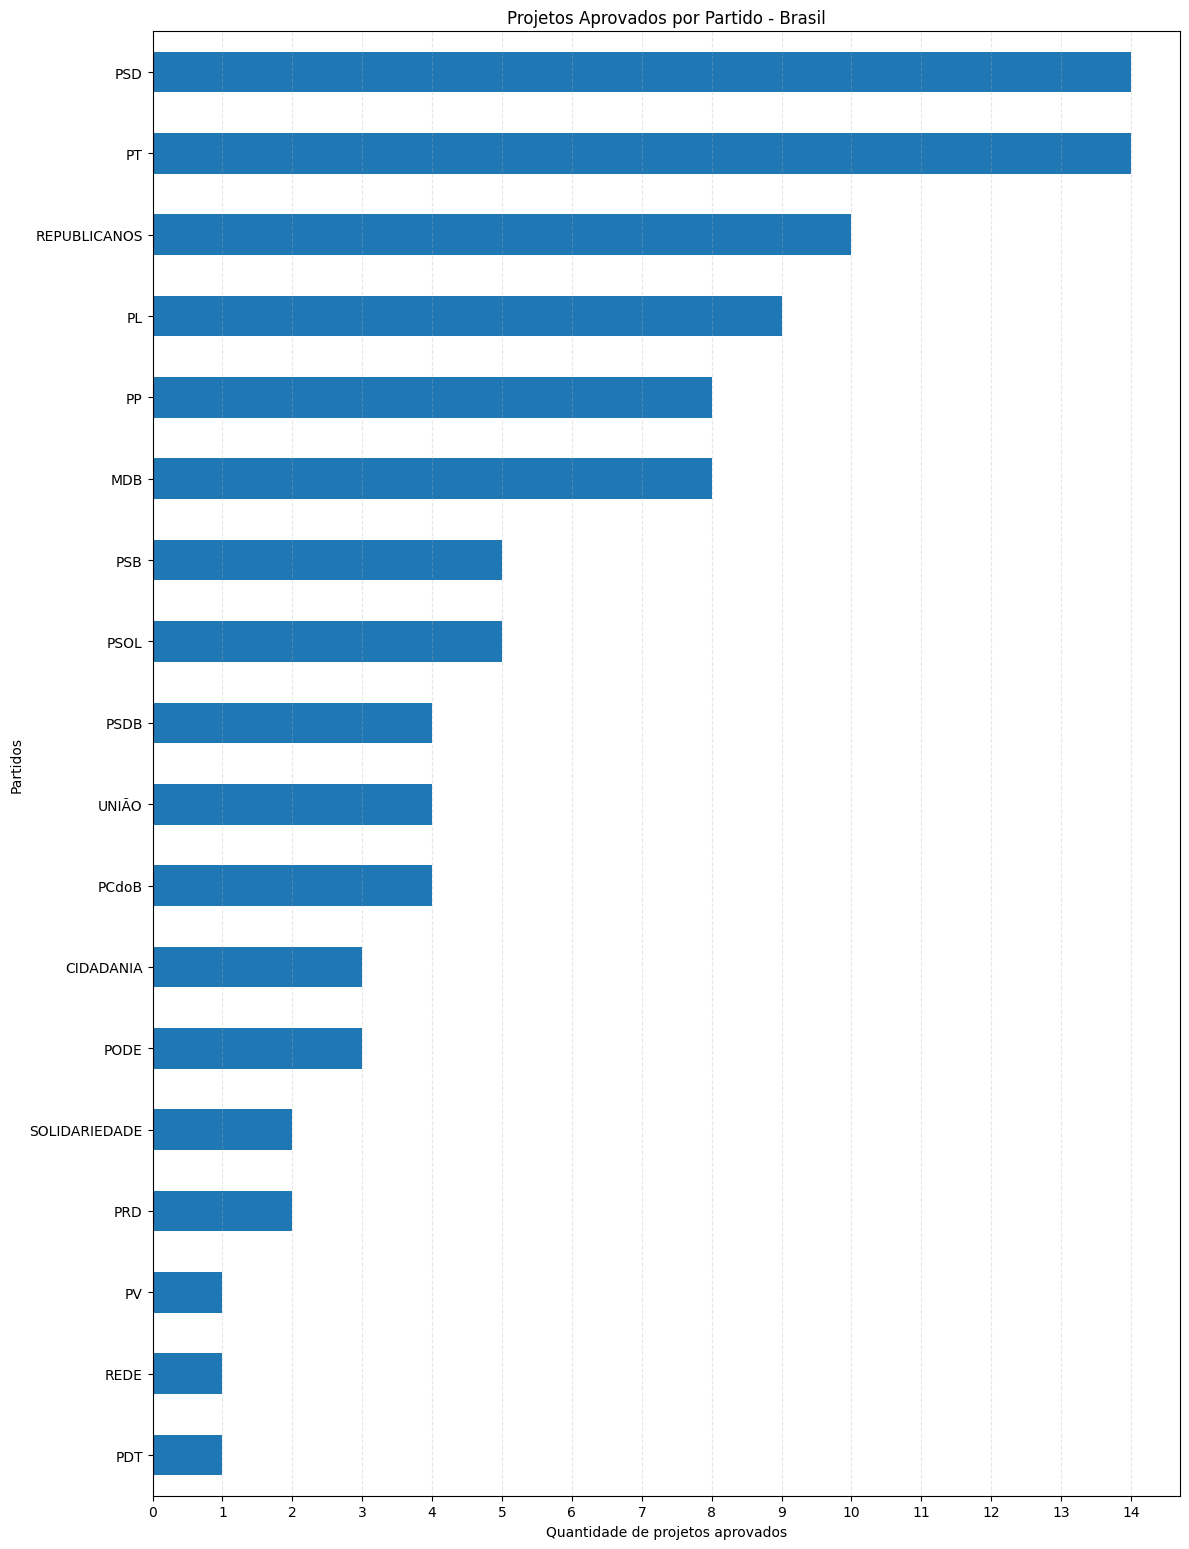

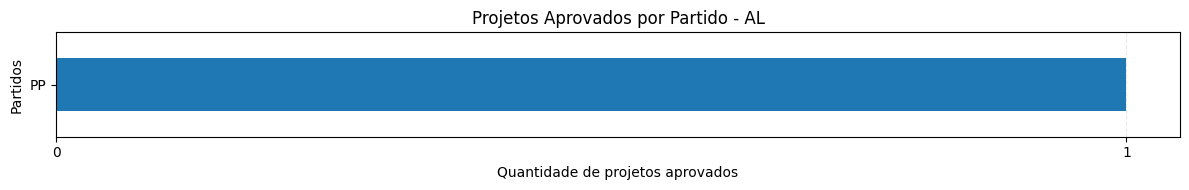

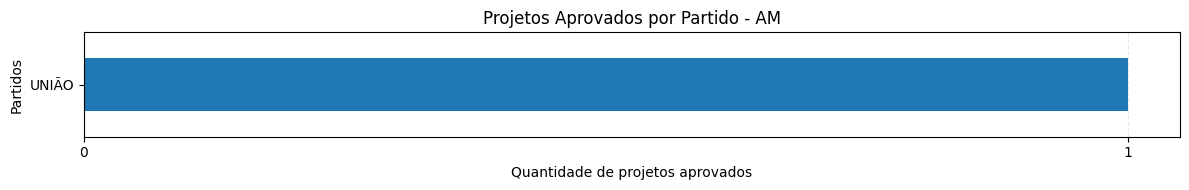

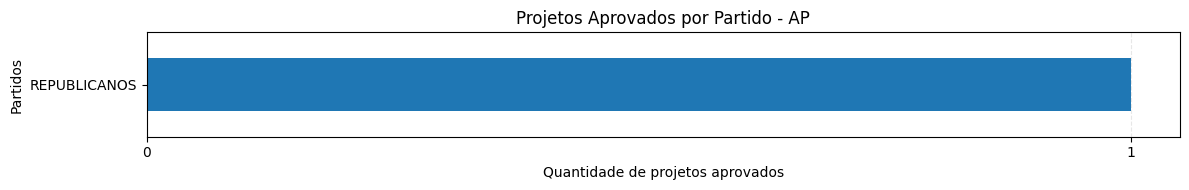

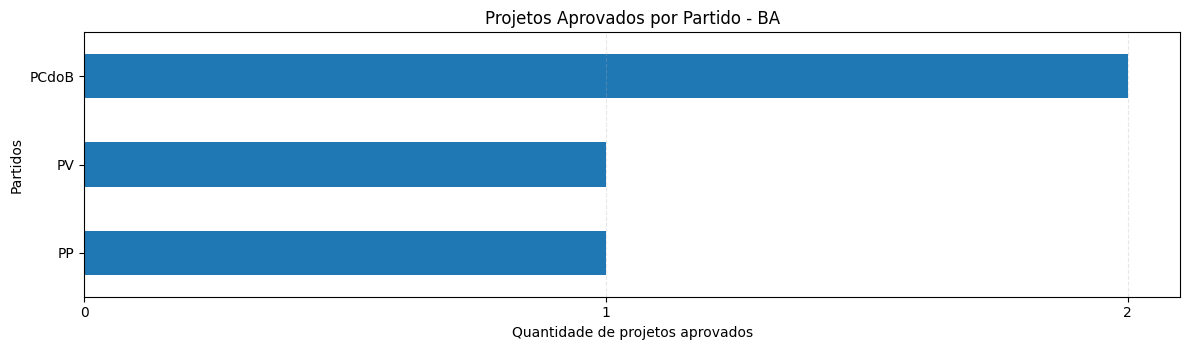

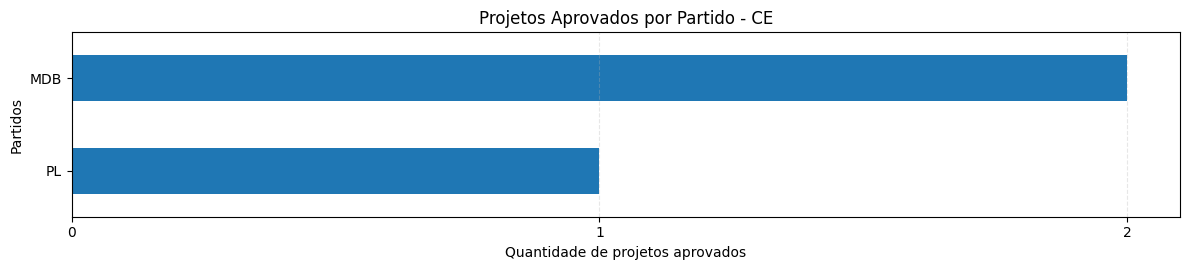

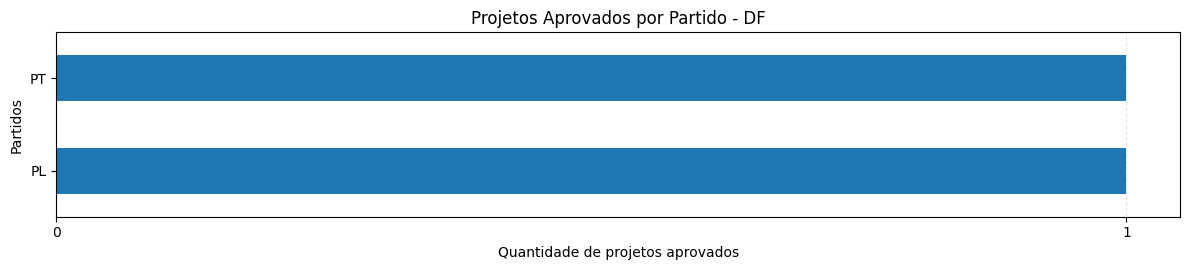

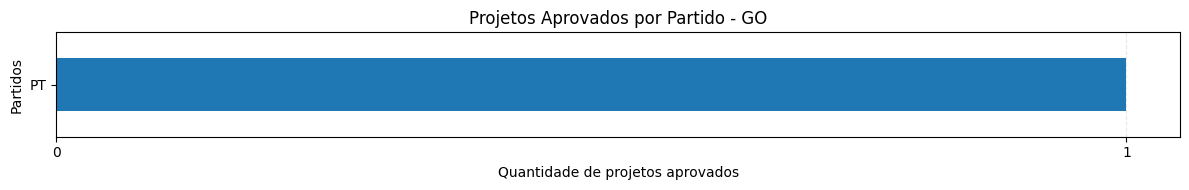

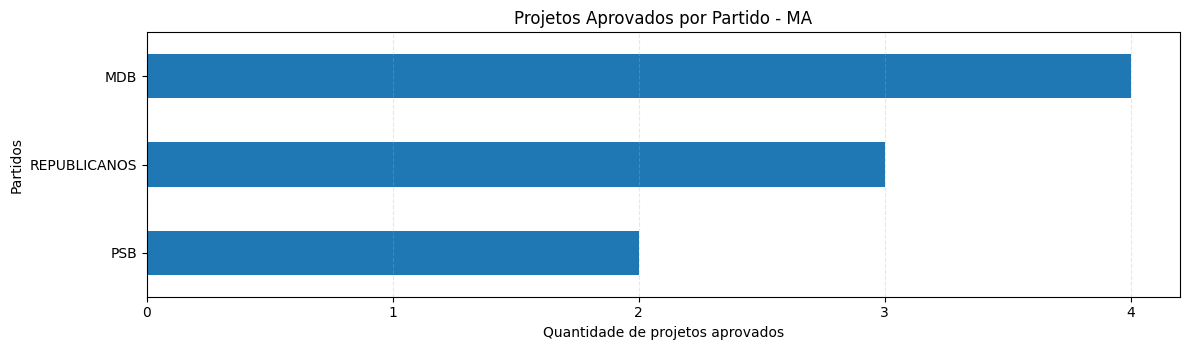

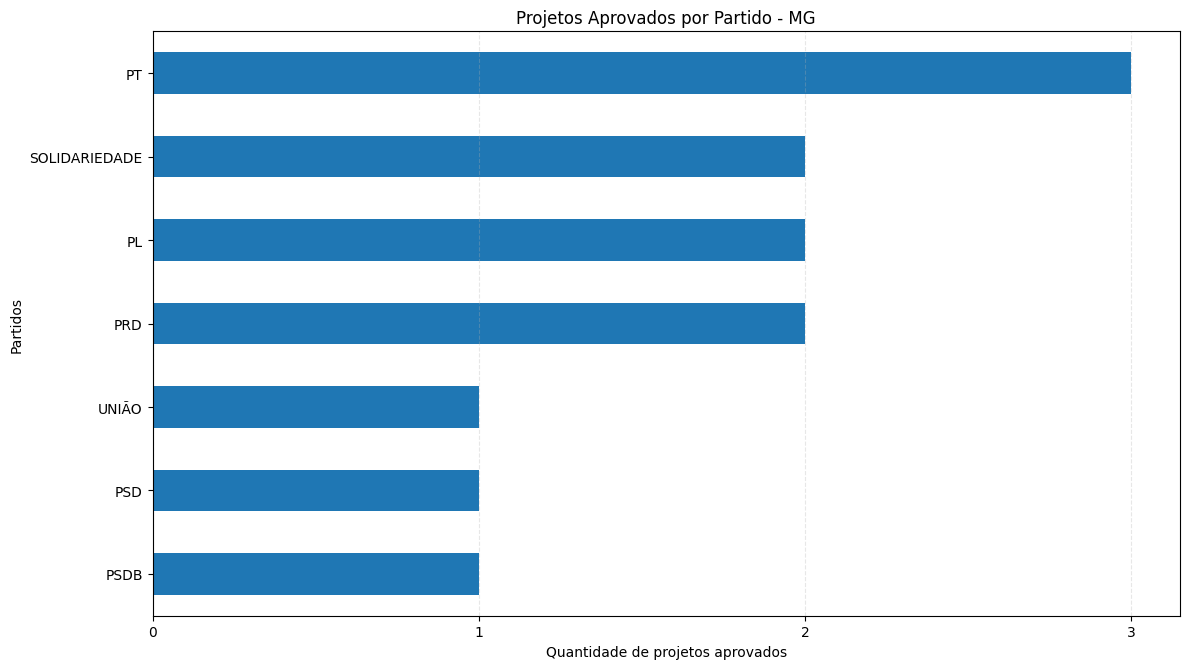

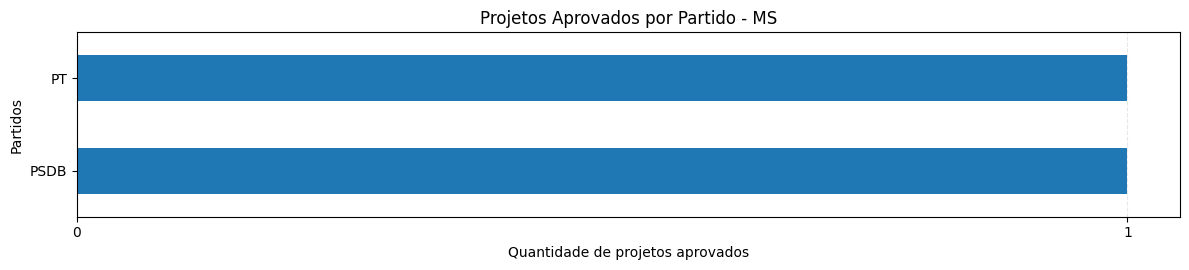

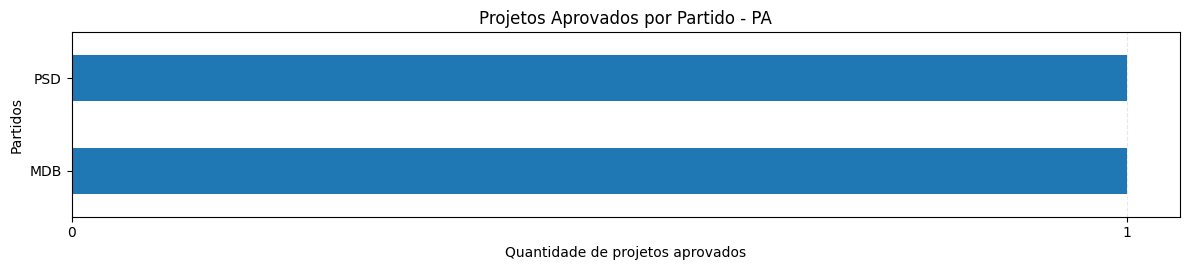

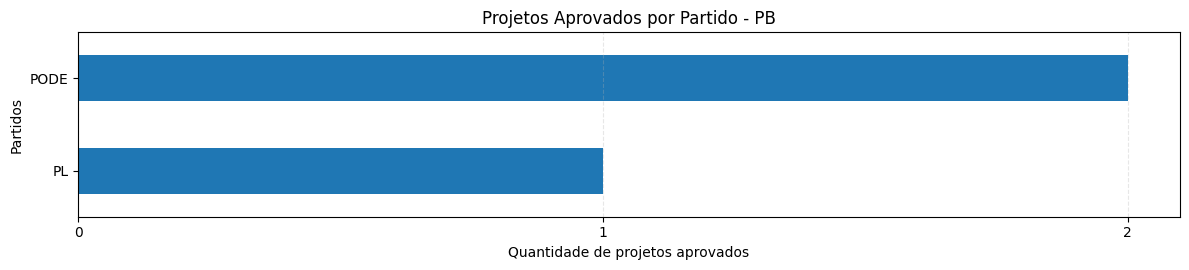

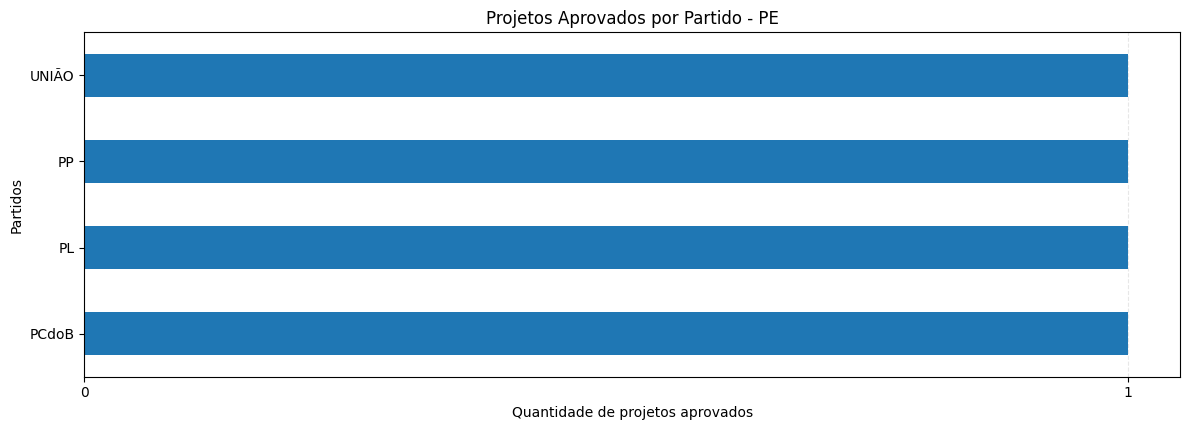

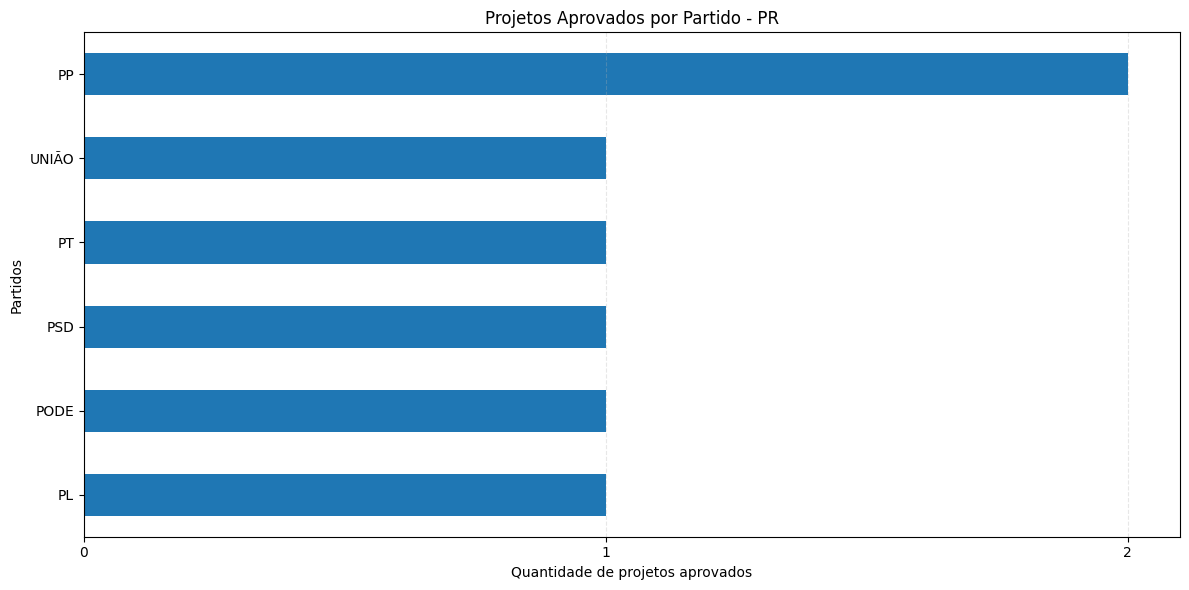

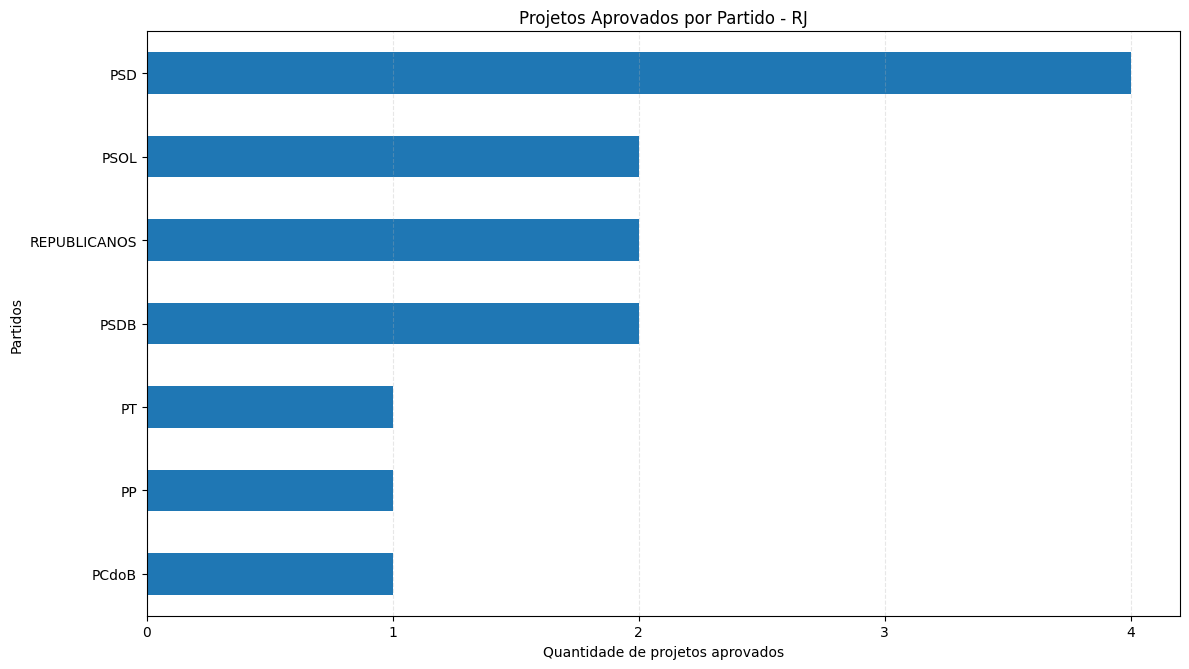

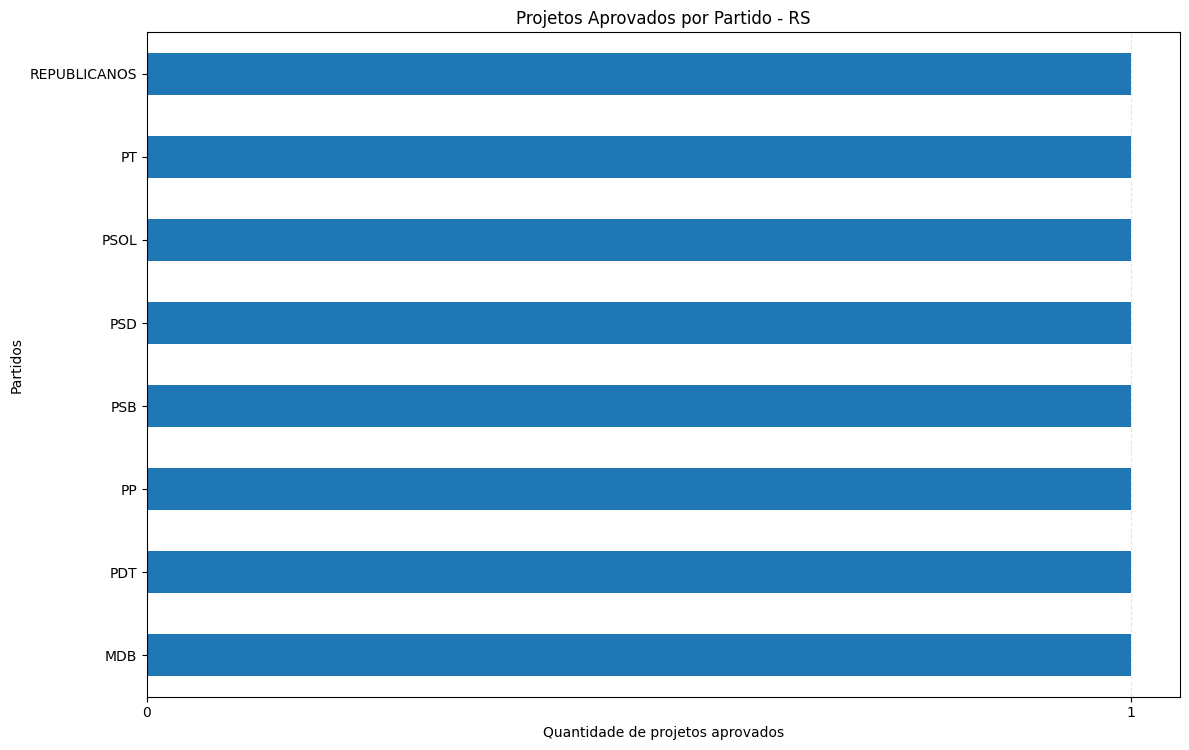

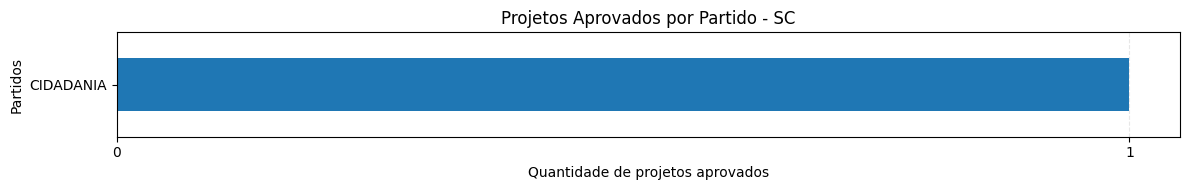

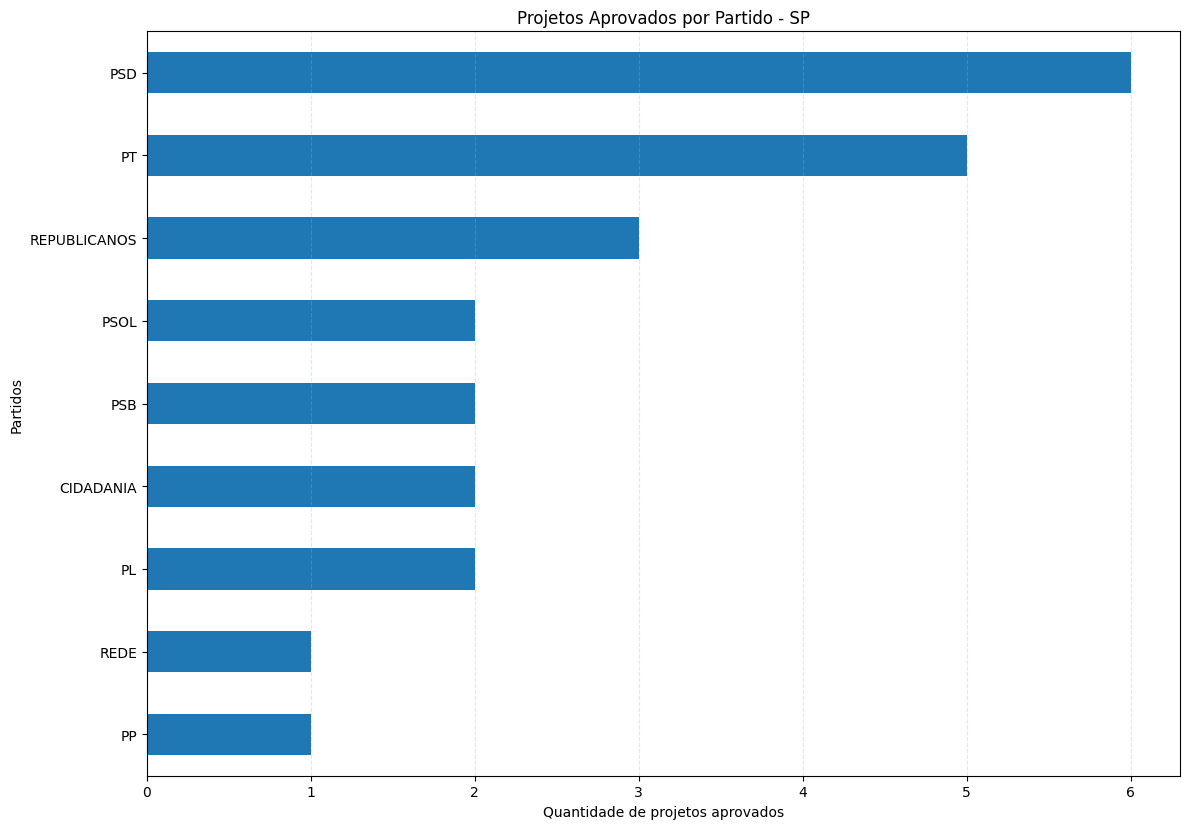

In [ ]:
# Importação das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import numpy as np

# URLs dos arquivos na branch específica do GitHub
url_df1 = 'https://raw.githubusercontent.com/APILumina/API1_DSM_Lumina/feature/codigos-graficos/data/deputados/deputados_detalhes_foto.csv'
url_df2 = 'https://raw.githubusercontent.com/APILumina/API1_DSM_Lumina/feature/codigos-graficos/data/deputados/ranking_projetos_filtrado.csv'

# Cria os dataFrame usando as URLs do GitHub
df1 = pd.read_csv(url_df1, sep=';')
df2 = pd.read_csv(url_df2, sep=';')

#  Apaga as colunas que não serão utilizadas
df1 = df1.drop(columns=['nome'])
df1 = df1.drop(columns=['id'])
df1 = df1.drop(columns=['cpf'])
df1 = df1.drop(columns=['urlFoto'])
df1 = df1.drop(columns=['situacao'])

# Deixa os nomes e os nome eleitorais com a mesma formatação
df1['nome_eleitoral'] = df1['nome_eleitoral'].str.strip().str.upper()
df2['nome'] = df2['nome'].str.strip().str.upper()

# Junta o df1 com df2
df_final = pd.merge(df1, df2, left_on='nome_eleitoral', right_on='nome')

# Criação graficos
def criaGrafico(df, estado):
    # Se o dataframe vier vazio, não faz nada
    if df.empty:
        return

    # Tamanho do gráfico que será gerado
    qtd_partidos = df['partido'].nunique()
    plt.figure(figsize=(12, 1.2 + (0.8 * qtd_partidos)))

    # Agrupa todos os projetos do mesmo partido, conta eles, deixa em ordem descrescente e desenha o gráfico com barras horizontais
    df.groupby('partido').size().sort_values().plot(kind='barh')

    # Configura os textos do gráfico
    plt.title(f'Projetos Aprovados por Partido - {estado}')
    plt.ylabel('Partidos')
    plt.xlabel('Quantidade de projetos aprovados')

    # Faz uma "régua" na parte de inferior do gráfico, que vai do 0 até o número máximo de projetos
    max_projetos = df.groupby('partido').size().max()
    plt.xticks(np.arange(0, max_projetos + 1, 1))

    # Cria um grid com linhas verticais
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    # Garante que todos os gráficos fiquem com o mesmo tamanho
    plt.tight_layout()

    # Garante que o gráfico seja mostrado
    plt.show()

    # Pula uma linha para separar os gráficos
    print()

# Gráfico dos projetos aprovados no Brasil
criaGrafico(df_final, 'Brasil')

# Lista os estados
estados = sorted(df_final['uf'].unique())

# Gráfico dos projetos aprovados pro estado
for uf in estados:
    df_estado = df_final[df_final['uf'] == uf]

    criaGrafico(df_estado, uf)
